# Rendering Library Benchmark

Сравнение библиотек рендеринга для Apple Silicon (M-chip).

**Выходы каждого рендерера:** `normals_camera` (H×W×3), `depth` (H×W), `pix_to_face` (H×W, int), `seg_mask` (H×W, int)

Окружение: `conda activate fusion_env`

In [21]:
import numpy as np
import time
from pathlib import Path
import matplotlib.pyplot as plt

DATA_DIR = Path('rendering_understanding_prep_data')
IMG_SIZE = 512
N_FRAMES = 5
FOV = 60

ASSEMBLIES = [
    '21243_3ec5d732',    # 172 faces,    2 parts  — smallest
    '20647_cea2e07c',    # 2044 faces,   5 parts
    '16550_e88d6986',    # 8610 faces,   2 parts
    '23176_1bf2a2d5',    # 12536 faces, 24 parts
    '21848_0fff9631',    # 12650 faces,  7 parts
    '20421_38b63ca5',    # 18088 faces, 16 parts
    '23233_ac09e2e5',    # 19004 faces, 17 parts
    '21977_ce9f4e71',    # 26244 faces,  4 parts
    '21316_69ed56f5',    # 91971 faces, 635 parts
    '20319_9f53cd7c',    # 189350 faces, 29 parts — largest
]

# ── load all meshes via trimesh (library-neutral loader) ─────────────────────
def _parse_obj(path):
    vs, fs = [], []
    for line in Path(path).read_text().splitlines():
        if line.startswith('v '):
            vs.append(list(map(float, line.split()[1:4])))
        elif line.startswith('f '):
            fs.append([int(t.split('/')[0]) - 1 for t in line.split()[1:4]])
    return np.array(vs, np.float32), np.array(fs, np.int32)

raw_meshes = {}
for name in ASSEMBLIES[:3]:
    p = DATA_DIR / name
    if not p.exists():
        print(f'skip {name} (not found)')
        continue
    try:
        import trimesh as _tm
        mesh_tm = _tm.load(str(p / 'combined_mesh.obj'), force='mesh', process=False)
        verts = np.array(mesh_tm.vertices, dtype=np.float32)
        faces = np.array(mesh_tm.faces, dtype=np.int32)
    except Exception:
        verts, faces = _parse_obj(p / 'combined_mesh.obj')
    face_labels = np.load(p / 'face_labels.npy')
    raw_meshes[name] = {'verts': verts, 'faces': faces, 'face_labels': face_labels}
    print(f'OK  {name}: {faces.shape[0]:>7} faces  {verts.shape[0]:>6} verts  {face_labels.max()} parts')

print(f'\nLoaded {len(raw_meshes)} meshes')

OK  21243_3ec5d732:     172 faces      88 verts  2 parts
OK  20647_cea2e07c:    2044 faces    1026 verts  5 parts
OK  16550_e88d6986:    8610 faces    4307 verts  2 parts

Loaded 3 meshes


In [22]:
# ── shared geometry + camera utils (adapted from step2_extract_outer_surface.py) ──

def mesh_center_radius(verts):
    c = verts.mean(axis=0)
    r = np.linalg.norm(verts - c, axis=1).max()
    return c, r

def random_camera_params(center, radius, fov_deg=FOV):
    """Same camera distribution as step2_extract_outer_surface.py."""
    elev = float(np.random.uniform(-90, 90))
    azim = float(np.random.uniform(0, 360))
    dist_min = radius / np.tan(np.radians(fov_deg / 2))
    dist = float(np.random.uniform(radius, 1.1 * dist_min))
    return elev, azim, dist

def compute_face_normals(verts, faces):
    v0, v1, v2 = verts[faces[:,0]], verts[faces[:,1]], verts[faces[:,2]]
    cross = np.cross(v1 - v0, v2 - v0)
    norms = np.linalg.norm(cross, axis=1, keepdims=True)
    return (cross / np.clip(norms, 1e-8, None)).astype(np.float32)

def normals_world_to_camera(nw, R):
    """nw: (N,3) world-space, R: (3,3) rotation matrix."""
    nc = nw @ R.T
    return nc / np.clip(np.linalg.norm(nc, axis=1, keepdims=True), 1e-8, None)

def verify_pix_to_face(ptf, ptf_gt):
    valid = ptf_gt >= 0
    return float('nan') if not valid.any() else float((ptf[valid] == ptf_gt[valid]).mean())

def lookat_matrix(eye, at, up=None):
    if up is None: up = np.array([0., 1., 0.], np.float32)
    f = at - eye; f /= np.linalg.norm(f)
    r = np.cross(f, up); r /= np.linalg.norm(r)
    u = np.cross(r, f)
    M = np.eye(4, dtype=np.float32)
    M[0,:3]=r; M[1,:3]=u; M[2,:3]=-f
    M[0,3]=-r@eye; M[1,3]=-u@eye; M[2,3]=f@eye
    return M

def perspective_matrix(fov_deg, aspect=1.0, near=0.01, far=1000.0):
    f = 1.0 / np.tan(np.radians(fov_deg) / 2)
    M = np.zeros((4,4), np.float32)
    M[0,0]=f/aspect; M[1,1]=f
    M[2,2]=(far+near)/(near-far); M[2,3]=(2*far*near)/(near-far); M[3,2]=-1
    return M

def elev_azim_to_eye(center, dist, elev_deg, azim_deg):
    e = np.radians(elev_deg); a = np.radians(azim_deg)
    return center + dist * np.array([np.cos(e)*np.sin(a), np.sin(e), np.cos(e)*np.cos(a)], np.float32)

# global stores
results     = {}   # results[lib][name] = {ms_per_frame, pix_to_face_acc}
baseline_ptf = {}  # baseline_ptf[name] = {cameras: [...], ptfs: [...]}
print('Utils ready')

Utils ready


---
## Approach 1 — PyTorch3D CPU (baseline)

In [23]:
# Step 1.1 — Install & Import
# Правильная установка pytorch3d на Apple Silicon + conda:
#   conda install pytorch3d -c pytorch3d
#   ИЛИ из source (если нет совместимого wheel):
#   FORCE_CUDA=0 pip install 'git+https://github.com/facebookresearch/pytorch3d.git'
#
# Проверка: версия torch в fusion_env должна совпадать с той, под которую собран wheel.
#   python -c 'import pytorch3d, torch; print(pytorch3d.__version__, torch.__version__)'
try:
    import torch
    import pytorch3d
    from pytorch3d.structures import Meshes
    from pytorch3d.renderer import (
        FoVPerspectiveCameras, RasterizationSettings, MeshRasterizer, look_at_view_transform
    )
    print(f'pytorch3d {pytorch3d.__version__},  torch {torch.__version__}')
    P3D_OK = True
except ImportError as e:
    print(f'FAIL: {e}')
    P3D_OK = False

pytorch3d 0.7.9,  torch 2.5.1


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99405986..0.99848676].


warm-up: 1804 ms  (16550_e88d6986)


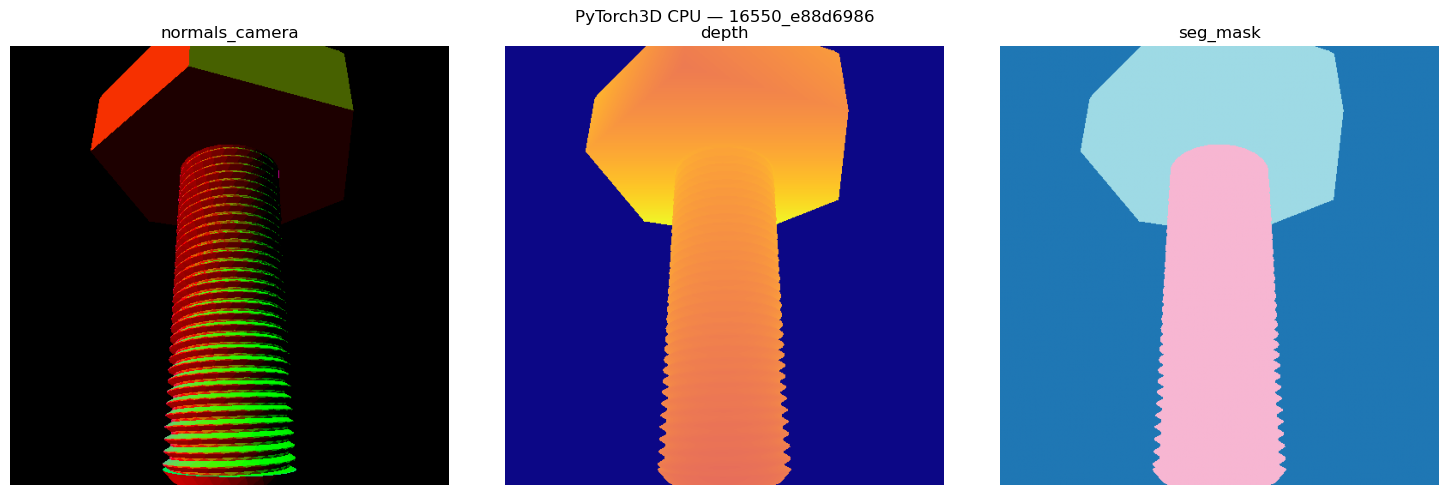

In [24]:
if P3D_OK:
    # Step 1.2/1.3 — mesh load + renderer init (timed)
    device_cpu = torch.device('cpu')
    raster_settings = RasterizationSettings(image_size=IMG_SIZE, blur_radius=0.0, faces_per_pixel=1)
    rasterizer_cpu  = MeshRasterizer(raster_settings=raster_settings)

    def render_p3d(verts_np, faces_np, face_normals_w, face_labels, elev, azim, dist, center, device):
        verts_t  = torch.from_numpy(verts_np).to(device)
        faces_t  = torch.from_numpy(faces_np).to(device)
        mesh     = Meshes(verts=[verts_t], faces=[faces_t])
        center_t = torch.tensor(center, device=device).unsqueeze(0)
        R, T = look_at_view_transform(dist=dist, elev=elev, azim=azim, at=center_t, device=device)
        cam  = FoVPerspectiveCameras(R=R, T=T, fov=FOV, device=device)
        # reuse CPU rasterizer; create new one per-call for other devices
        rast = rasterizer_cpu if device.type == 'cpu' else MeshRasterizer(raster_settings=raster_settings)
        frags = rast(mesh, cameras=cam)

        pix  = frags.pix_to_face[0,:,:,0].cpu().numpy().astype(np.int32)
        zbuf = frags.zbuf[0,:,:,0].cpu().numpy().astype(np.float32)
        valid = pix >= 0
        seg = np.full_like(pix, -1)
        seg[valid] = face_labels[pix[valid]]
        nc = np.zeros((IMG_SIZE, IMG_SIZE, 3), np.float32)
        if valid.any():
            nc[valid] = normals_world_to_camera(face_normals_w[pix[valid]], R[0].cpu().numpy())
        return {'pix_to_face': pix, 'depth': zbuf, 'normals_camera': nc, 'seg_mask': seg}

    # Step 1.4 — warm-up + visualise
    np.random.seed(42)
    name0 = list(raw_meshes.keys())[2]  # ~8k faces
    m0    = raw_meshes[name0]
    fn_w0 = compute_face_normals(m0['verts'], m0['faces'])
    c0, r0 = mesh_center_radius(m0['verts'])
    e0, a0, d0 = random_camera_params(c0, r0)

    t0 = time.perf_counter()
    out0 = render_p3d(m0['verts'], m0['faces'], fn_w0, m0['face_labels'], e0, a0, d0, c0, device_cpu)
    print(f'warm-up: {(time.perf_counter()-t0)*1000:.0f} ms  ({name0})')

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(out0['normals_camera']); axes[0].set_title('normals_camera')
    axes[1].imshow(out0['depth'], cmap='plasma'); axes[1].set_title('depth')
    axes[2].imshow(out0['seg_mask'], cmap='tab20'); axes[2].set_title('seg_mask')
    for ax in axes: ax.axis('off')
    plt.suptitle(f'PyTorch3D CPU — {name0}'); plt.tight_layout(); plt.show()

In [25]:
# Step 1.5 — benchmark N_FRAMES × all 10 meshes, store as baseline
if P3D_OK:
    np.random.seed(42)
    lib = 'PyTorch3D CPU'
    results[lib] = {}
    for name, m in raw_meshes.items():
        fn_w  = compute_face_normals(m['verts'], m['faces'])
        c, _  = mesh_center_radius(m['verts'])
        cams  = [random_camera_params(c, _) for _ in [mesh_center_radius(m['verts'])[1]] * N_FRAMES]
        # fix: generate N_FRAMES cameras properly
        _, r = mesh_center_radius(m['verts'])
        cams = [random_camera_params(c, r) for _ in range(N_FRAMES)]
        baseline_ptf[name] = {'cameras': cams, 'ptfs': []}

        times = []
        for elev, azim, dist in cams:
            t0  = time.perf_counter()
            out = render_p3d(m['verts'], m['faces'], fn_w, m['face_labels'],
                             elev, azim, dist, c, device_cpu)
            times.append((time.perf_counter() - t0) * 1000)
            baseline_ptf[name]['ptfs'].append(out['pix_to_face'].copy())

        ms = np.mean(times)
        results[lib][name] = {'ms_per_frame': ms, 'pix_to_face_acc': 1.0}
        print(f'  {name}: {ms:7.1f} ms/frame  ({m["faces"].shape[0]} faces)')

  21243_3ec5d732:    79.7 ms/frame  (172 faces)
  20647_cea2e07c:   633.5 ms/frame  (2044 faces)
  16550_e88d6986:  2308.5 ms/frame  (8610 faces)


---
## Approach 2 — PyTorch3D MPS

In [26]:
# Step 2.1 — MPS check
# Если pytorch3d падает на MPS — wheel собран без MPS kernel support.
# Пересобрать:
#   FORCE_CUDA=0 pip install 'git+https://github.com/facebookresearch/pytorch3d.git'
# На Colab (CUDA): тот же render_p3d(), device='cuda'.
import torch
MPS_OK = False
if P3D_OK and torch.backends.mps.is_available():
    print(f'MPS available, torch {torch.__version__}')
    MPS_OK = True
else:
    msg = 'MPS not available' if not torch.backends.mps.is_available() else 'pytorch3d not loaded'
    print(f'{msg}  →  на Colab: device=cuda, тот же код')

MPS available, torch 2.5.1


In [27]:
if MPS_OK:
    mps_dev = torch.device('mps')
    lib = 'PyTorch3D MPS'
    results[lib] = {}
    try:
        for name, m in raw_meshes.items():
            fn_w = compute_face_normals(m['verts'], m['faces'])
            c, _ = mesh_center_radius(m['verts'])
            times, accs = [], []
            for i, (elev, azim, dist) in enumerate(baseline_ptf[name]['cameras']):
                t0 = time.perf_counter()
                out = render_p3d(m['verts'], m['faces'], fn_w, m['face_labels'],
                                 elev, azim, dist, c, mps_dev)
                torch.mps.synchronize()
                times.append((time.perf_counter() - t0) * 1000)
                accs.append(verify_pix_to_face(out['pix_to_face'], baseline_ptf[name]['ptfs'][i]))
            ms = np.mean(times); acc = np.mean(accs)
            results[lib][name] = {'ms_per_frame': ms, 'pix_to_face_acc': acc}
            print(f'  {name}: {ms:7.1f} ms/frame  acc={acc:.4f}')
    except Exception as e:
        import traceback; traceback.print_exc()
        print('\nFix: FORCE_CUDA=0 pip install git+https://github.com/facebookresearch/pytorch3d.git')


Fix: FORCE_CUDA=0 pip install git+https://github.com/facebookresearch/pytorch3d.git


Traceback (most recent call last):
  File "/var/folders/nn/mgs_bzg54359bbbfz3j0th4h0000gn/T/ipykernel_97102/1773256314.py", line 12, in <module>
    out = render_p3d(m['verts'], m['faces'], fn_w, m['face_labels'],
  File "/var/folders/nn/mgs_bzg54359bbbfz3j0th4h0000gn/T/ipykernel_97102/887912698.py", line 16, in render_p3d
    frags = rast(mesh, cameras=cam)
  File "/Users/neonilllai/miniconda3/envs/fusion_env/lib/python3.10/site-packages/torch/nn/modules/module.py", line 1736, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/Users/neonilllai/miniconda3/envs/fusion_env/lib/python3.10/site-packages/torch/nn/modules/module.py", line 1747, in _call_impl
    return forward_call(*args, **kwargs)
  File "/Users/neonilllai/miniconda3/envs/fusion_env/lib/python3.10/site-packages/pytorch3d/renderer/mesh/rasterizer.py", line 254, in forward
    pix_to_face, zbuf, bary_coords, dists = rasterize_meshes(
  File "/Users/neonilllai/miniconda3/envs/fusion_env/lib/python3.10/s

---
## Approach 3 — ModernGL (OpenGL MRT: все выходы за один draw call)

In [ ]:
# Step 3.1 — Install & Import
# ARM64 wheel доступен с Oct 2024. OpenGL работает через NSOpenGL на macOS.
#   pip install moderngl
# Если ошибка 'could not create context':
#   pip install moderngl[headless]
try:
    import moderngl
    ctx = moderngl.create_standalone_context()
    print(f'moderngl {moderngl.__version__},  OpenGL {ctx.version_code}')
    print(f'Vendor:   {ctx.info["GL_VENDOR"]}')
    print(f'Renderer: {ctx.info["GL_RENDERER"]}')
    MGL_OK = True
except Exception as e:
    print(f'FAIL: {e}')
    print('Install: pip install moderngl')
    MGL_OK = False

In [ ]:
if MGL_OK:
    # Step 3.3 — GLSL program + framebuffer with 3 MRT attachments
    VERT = '''
#version 330 core
in vec3 in_pos; in vec3 in_norm; flat in int in_fid;
out vec3 v_nc; flat out int v_fid; out float v_depth;
uniform mat4 MVP; uniform mat3 NM;
void main() {
    vec4 clip = MVP * vec4(in_pos, 1.0);
    gl_Position = clip;
    v_nc    = normalize(NM * in_norm);
    v_fid   = in_fid;
    v_depth = clip.z / clip.w;
}
    '''
    FRAG = '''
#version 330 core
in vec3 v_nc; flat in int v_fid; in float v_depth;
layout(location=0) out vec4  out_normals;
layout(location=1) out float out_depth;
layout(location=2) out int   out_fid;
void main() {
    out_normals = vec4(v_nc, 1.0);
    out_depth   = v_depth;
    out_fid     = v_fid;
}
    '''
    try:
        mgl_prog = ctx.program(vertex_shader=VERT, fragment_shader=FRAG)
        mgl_tex_n = ctx.texture((IMG_SIZE, IMG_SIZE), 4, dtype='f4')
        mgl_tex_d = ctx.texture((IMG_SIZE, IMG_SIZE), 1, dtype='f4')
        mgl_tex_f = ctx.texture((IMG_SIZE, IMG_SIZE), 1, dtype='i4')
        mgl_fbo   = ctx.framebuffer(
            color_attachments=[mgl_tex_n, mgl_tex_d, mgl_tex_f],
            depth_attachment=ctx.depth_renderbuffer((IMG_SIZE, IMG_SIZE))
        )
        print('GLSL compiled — 3 MRT: normals(rgba32f) + depth(r32f) + face_id(r32i)')
    except Exception as e:
        print(f'FAIL shader/FBO: {e}'); MGL_OK = False

In [ ]:
if MGL_OK:
    import struct as _st

    def _mgl_vbo(verts, faces, face_normals_w):
        """Pack triangles into interleaved buffer: pos(3f) norm(3f) face_id(1i) = 28B."""
        tv = verts[faces].reshape(-1, 3).astype(np.float32)        # (3F, 3)
        tn = np.repeat(face_normals_w, 3, axis=0).astype(np.float32)  # (3F, 3)
        fids = np.repeat(np.arange(len(faces), dtype=np.int32), 3)    # (3F,)
        flat = np.hstack([tv, tn])  # (3F, 6)
        parts = []
        for i in range(len(fids)):
            parts.append(flat[i].tobytes())
            parts.append(_st.pack('i', int(fids[i])))
        return b''.join(parts)

    def render_moderngl(verts, faces, face_normals_w, face_labels, elev, azim, dist, center):
        eye = elev_azim_to_eye(center, dist, elev, azim)
        V   = lookat_matrix(eye, center.astype(np.float32))
        P   = perspective_matrix(FOV)
        MVP = P @ V
        NM  = np.linalg.inv(V[:3,:3]).T.astype(np.float32)

        vbo_data = _mgl_vbo(verts, faces, face_normals_w)
        vbo = ctx.buffer(vbo_data)
        vao = ctx.vertex_array(mgl_prog, [(vbo, '3f 3f 1i', 'in_pos', 'in_norm', 'in_fid')])

        mgl_fbo.use()
        ctx.clear(0, 0, 0, 0)
        ctx.enable(moderngl.DEPTH_TEST)
        mgl_prog['MVP'].write(MVP.T.astype(np.float32).tobytes())
        mgl_prog['NM'].write(NM.T.tobytes())
        vao.render(moderngl.TRIANGLES)
        ctx.finish()

        nc  = np.flipud(np.frombuffer(mgl_tex_n.read(), np.float32).reshape(IMG_SIZE, IMG_SIZE, 4))[:,:,:3]
        dep = np.flipud(np.frombuffer(mgl_tex_d.read(), np.float32).reshape(IMG_SIZE, IMG_SIZE))
        pix = np.flipud(np.frombuffer(mgl_tex_f.read(), np.int32 ).reshape(IMG_SIZE, IMG_SIZE))

        valid   = np.linalg.norm(nc, axis=-1) > 0.01
        pix_out = np.where(valid, pix, -1).astype(np.int32)
        seg     = np.full_like(pix_out, -1)
        seg[pix_out >= 0] = face_labels[pix_out[pix_out >= 0]]

        vao.release(); vbo.release()
        return {'pix_to_face': pix_out, 'depth': dep, 'normals_camera': nc, 'seg_mask': seg}

    # warm-up + visualise
    m0 = raw_meshes[list(raw_meshes.keys())[2]]
    fn0 = compute_face_normals(m0['verts'], m0['faces'])
    c0, _ = mesh_center_radius(m0['verts'])
    e0, a0, d0 = baseline_ptf[list(raw_meshes.keys())[2]]['cameras'][0]
    t0 = time.perf_counter()
    out_mgl = render_moderngl(m0['verts'], m0['faces'], fn0, m0['face_labels'], e0, a0, d0, c0)
    print(f'warm-up: {(time.perf_counter()-t0)*1000:.0f} ms')

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow((out_mgl['normals_camera']+1)*0.5); axes[0].set_title('normals_camera')
    axes[1].imshow(out_mgl['depth'], cmap='plasma'); axes[1].set_title('depth')
    axes[2].imshow(out_mgl['seg_mask'], cmap='tab20'); axes[2].set_title('seg_mask')
    for ax in axes: ax.axis('off')
    plt.suptitle(f'ModernGL — {list(raw_meshes.keys())[2]}'); plt.tight_layout(); plt.show()

In [ ]:
if MGL_OK:
    lib = 'ModernGL'
    results[lib] = {}
    for name, m in raw_meshes.items():
        fn_w = compute_face_normals(m['verts'], m['faces'])
        c, _ = mesh_center_radius(m['verts'])
        times, accs = [], []
        for i, (elev, azim, dist) in enumerate(baseline_ptf[name]['cameras']):
            t0 = time.perf_counter()
            out = render_moderngl(m['verts'], m['faces'], fn_w, m['face_labels'], elev, azim, dist, c)
            times.append((time.perf_counter()-t0)*1000)
            accs.append(verify_pix_to_face(out['pix_to_face'], baseline_ptf[name]['ptfs'][i]))
        ms = np.mean(times); acc = np.mean(accs)
        results[lib][name] = {'ms_per_frame': ms, 'pix_to_face_acc': acc}
        print(f'  {name}: {ms:7.1f} ms/frame  acc={acc:.4f}')

---
## Approach 4 — wgpu-py (Metal backend via WebGPU, WGSL shader)

In [ ]:
# Step 4.1 — Install & Import
# wgpu-py — Rust wgpu под капотом, нативный Metal на Apple Silicon.
#   pip install wgpu
# Проверяем backend = Metal.
try:
    import wgpu
    adapter   = wgpu.gpu.request_adapter_sync(power_preference='high-performance')
    wgpu_dev  = adapter.request_device_sync()
    info = adapter.info
    print(f'wgpu {wgpu.__version__}')
    print(f'Backend:  {info.get("backend_type", info.get("adapter_type", "?"))}')
    print(f'GPU:      {info.get("description", "?")}')
    WGPU_OK = True
except Exception as e:
    print(f'FAIL: {e}')
    print('Install: pip install wgpu')
    WGPU_OK = False

In [ ]:
if WGPU_OK:
    WGSL = '''
struct Uni { mvp: mat4x4<f32>, nm: mat4x4<f32> };
@group(0) @binding(0) var<uniform> u: Uni;
struct VI { @location(0) pos: vec3<f32>, @location(1) norm: vec3<f32>, @location(2) fid: i32 };
struct VO {
    @builtin(position) clip: vec4<f32>,
    @location(0) nc: vec3<f32>,
    @location(1) @interpolate(flat) fid: i32
};
@vertex fn vs(v: VI) -> VO {
    var o: VO;
    o.clip = u.mvp * vec4<f32>(v.pos, 1.0);
    o.nc   = normalize((u.nm * vec4<f32>(v.norm, 0.0)).xyz);
    o.fid  = v.fid;
    return o;
}
struct FO { @location(0) nc: vec4<f32>, @location(1) fid: i32 };
@fragment fn fs(i: VO) -> FO {
    return FO(vec4<f32>(i.nc, 1.0), i.fid);
}
    '''
    try:
        wgpu_shader = wgpu_dev.create_shader_module(code=WGSL)
        wg_tex_n = wgpu_dev.create_texture({'size':(IMG_SIZE,IMG_SIZE,1),
            'format': wgpu.TextureFormat.rgba32float,
            'usage': wgpu.TextureUsage.RENDER_ATTACHMENT | wgpu.TextureUsage.COPY_SRC})
        wg_tex_f = wgpu_dev.create_texture({'size':(IMG_SIZE,IMG_SIZE,1),
            'format': wgpu.TextureFormat.r32sint,
            'usage': wgpu.TextureUsage.RENDER_ATTACHMENT | wgpu.TextureUsage.COPY_SRC})
        wg_tex_ds = wgpu_dev.create_texture({'size':(IMG_SIZE,IMG_SIZE,1),
            'format': wgpu.TextureFormat.depth32float,
            'usage': wgpu.TextureUsage.RENDER_ATTACHMENT})
        wg_bgl = wgpu_dev.create_bind_group_layout(entries=[{
            'binding':0,'visibility':wgpu.ShaderStage.VERTEX,
            'buffer':{'type':wgpu.BufferBindingType.uniform}}])
        wg_pl = wgpu_dev.create_pipeline_layout(bind_group_layouts=[wg_bgl])
        wg_pipe = wgpu_dev.create_render_pipeline({
            'layout': wg_pl,
            'vertex': {'module': wgpu_shader, 'entry_point': 'vs',
                'buffers': [{'array_stride':28,'step_mode':wgpu.VertexStepMode.vertex,'attributes':[
                    {'shader_location':0,'offset':0,'format':wgpu.VertexFormat.float32x3},
                    {'shader_location':1,'offset':12,'format':wgpu.VertexFormat.float32x3},
                    {'shader_location':2,'offset':24,'format':wgpu.VertexFormat.sint32}
                ]}]},
            'fragment': {'module': wgpu_shader, 'entry_point': 'fs',
                'targets': [{'format':wgpu.TextureFormat.rgba32float},
                            {'format':wgpu.TextureFormat.r32sint}]},
            'primitive': {'topology':wgpu.PrimitiveTopology.triangle_list,'cull_mode':wgpu.CullMode.none},
            'depth_stencil': {'format':wgpu.TextureFormat.depth32float,
                'depth_write_enabled':True,'depth_compare':wgpu.CompareFunction.less_equal},
        })
        print('WGSL compiled + pipeline ready')
    except Exception as e:
        print(f'FAIL pipeline: {e}'); WGPU_OK = False

In [ ]:
if WGPU_OK:
    import struct as _st

    def _wgpu_read(tex, dtype, n_ch):
        nb = IMG_SIZE * IMG_SIZE * n_ch * np.dtype(dtype).itemsize
        bpr = IMG_SIZE * n_ch * np.dtype(dtype).itemsize
        buf = wgpu_dev.create_buffer({'size':nb,
            'usage':wgpu.BufferUsage.COPY_DST|wgpu.BufferUsage.MAP_READ})
        enc = wgpu_dev.create_command_encoder()
        enc.copy_texture_to_buffer(
            {'texture':tex,'mip_level':0,'origin':(0,0,0)},
            {'buffer':buf,'offset':0,'bytes_per_row':bpr,'rows_per_image':IMG_SIZE},
            (IMG_SIZE,IMG_SIZE,1))
        wgpu_dev.queue.submit([enc.finish()])
        data = bytes(buf.map_read(0, nb))
        buf.unmap()
        arr = np.frombuffer(data, dtype)
        return arr.reshape(IMG_SIZE, IMG_SIZE, n_ch) if n_ch > 1 else arr.reshape(IMG_SIZE, IMG_SIZE)

    def render_wgpu(verts, faces, face_normals_w, face_labels, elev, azim, dist, center):
        nf = len(faces)
        tv = verts[faces].reshape(-1,3).astype(np.float32)
        tn = np.repeat(face_normals_w,3,axis=0).astype(np.float32)
        fi = np.repeat(np.arange(nf, dtype=np.int32), 3)
        parts = []
        for i in range(len(fi)):
            parts += [tv[i].tobytes(), tn[i].tobytes(), _st.pack('i', int(fi[i]))]
        vbo = wgpu_dev.create_buffer_with_data(data=b''.join(parts), usage=wgpu.BufferUsage.VERTEX)

        eye = elev_azim_to_eye(center, dist, elev, azim)
        V   = lookat_matrix(eye, center.astype(np.float32))
        MVP = (perspective_matrix(FOV) @ V).astype(np.float32)
        nm4 = np.eye(4, dtype=np.float32); nm4[:3,:3] = np.linalg.inv(V[:3,:3]).T
        ub  = wgpu_dev.create_buffer_with_data(
            data=MVP.T.tobytes() + nm4.T.tobytes(), usage=wgpu.BufferUsage.UNIFORM)
        bg  = wgpu_dev.create_bind_group(layout=wg_bgl, entries=[{
            'binding':0,'resource':{'buffer':ub,'offset':0,'size':128}}])

        enc = wgpu_dev.create_command_encoder()
        rp  = enc.begin_render_pass(
            color_attachments=[
                {'view':wg_tex_n.create_view(),'load_op':wgpu.LoadOp.clear,
                 'store_op':wgpu.StoreOp.store,'clear_value':(0,0,0,0)},
                {'view':wg_tex_f.create_view(),'load_op':wgpu.LoadOp.clear,
                 'store_op':wgpu.StoreOp.store,'clear_value':(-1,0,0,0)}
            ],
            depth_stencil_attachment={
                'view':wg_tex_ds.create_view(),'depth_load_op':wgpu.LoadOp.clear,
                'depth_store_op':wgpu.StoreOp.store,'depth_clear_value':1.0})
        rp.set_pipeline(wg_pipe); rp.set_bind_group(0,bg)
        rp.set_vertex_buffer(0,vbo); rp.draw(nf*3); rp.end()
        wgpu_dev.queue.submit([enc.finish()])

        nc  = _wgpu_read(wg_tex_n, np.float32, 4)[:,:,:3]
        fid = _wgpu_read(wg_tex_f, np.int32,   1)
        valid = fid >= 0
        seg = np.full_like(fid, -1)
        seg[valid] = face_labels[fid[valid]]
        return {'pix_to_face':fid, 'depth':np.zeros_like(fid, np.float32), 'normals_camera':nc, 'seg_mask':seg}

    # warm-up + visualise
    name0 = list(raw_meshes.keys())[2]
    m0 = raw_meshes[name0]; fn0 = compute_face_normals(m0['verts'],m0['faces'])
    c0, _ = mesh_center_radius(m0['verts'])
    e0,a0,d0 = baseline_ptf[name0]['cameras'][0]
    try:
        t0 = time.perf_counter()
        out_wg = render_wgpu(m0['verts'],m0['faces'],fn0,m0['face_labels'],e0,a0,d0,c0)
        print(f'warm-up: {(time.perf_counter()-t0)*1000:.0f} ms')
        fig, axes = plt.subplots(1,3,figsize=(15,5))
        axes[0].imshow((out_wg['normals_camera']+1)*0.5); axes[0].set_title('normals_camera')
        axes[1].imshow(out_wg['pix_to_face'],cmap='nipy_spectral'); axes[1].set_title('pix_to_face')
        axes[2].imshow(out_wg['seg_mask'],cmap='tab20'); axes[2].set_title('seg_mask')
        for ax in axes: ax.axis('off')
        plt.suptitle(f'wgpu — {name0}'); plt.tight_layout(); plt.show()
    except Exception as e:
        import traceback; traceback.print_exc(); WGPU_OK = False

In [ ]:
if WGPU_OK:
    lib = 'wgpu'
    results[lib] = {}
    for name, m in raw_meshes.items():
        fn_w = compute_face_normals(m['verts'],m['faces'])
        c, _ = mesh_center_radius(m['verts'])
        times, accs = [], []
        try:
            for i,(elev,azim,dist) in enumerate(baseline_ptf[name]['cameras']):
                t0 = time.perf_counter()
                out = render_wgpu(m['verts'],m['faces'],fn_w,m['face_labels'],elev,azim,dist,c)
                times.append((time.perf_counter()-t0)*1000)
                accs.append(verify_pix_to_face(out['pix_to_face'], baseline_ptf[name]['ptfs'][i]))
        except Exception as e:
            print(f'  {name}: FAIL {e}'); continue
        ms=np.mean(times); acc=np.mean(accs)
        results[lib][name]={'ms_per_frame':ms,'pix_to_face_acc':acc}
        print(f'  {name}: {ms:7.1f} ms/frame  acc={acc:.4f}')

---
## Approach 5 — Taichi (Metal GPU, custom triangle rasterizer)

In [ ]:
# Step 5.1 — Install & Import
# ARM64 wheels для Python 3.8-3.11. ti.gpu = Metal на macOS.
#   pip install taichi
try:
    import taichi as ti
    ti.init(arch=ti.gpu, default_fp=ti.f32, default_ip=ti.i32)
    print(f'taichi {ti.__version__},  backend: {ti.cfg.arch}')
    TAICHI_OK = True
except Exception as e:
    print(f'FAIL: {e}')
    print('Install: pip install taichi')
    TAICHI_OK = False

In [ ]:
if TAICHI_OK:
    # Step 5.2 — define kernel fields (allocated once)
    MAX_F = 300_000
    H_, W_ = IMG_SIZE, IMG_SIZE

    buf_nc  = ti.Vector.field(3, ti.f32, shape=(H_, W_))
    buf_dep = ti.field(ti.f32,           shape=(H_, W_))
    buf_fid = ti.field(ti.i32,           shape=(H_, W_))
    buf_z   = ti.field(ti.i32,           shape=(H_, W_))  # int depth for atomics

    tv_buf  = ti.Vector.field(3, ti.f32, shape=MAX_F * 3)
    tn_buf  = ti.Vector.field(3, ti.f32, shape=MAX_F)

    @ti.kernel
    def _clear():
        for y, x in buf_nc:
            buf_nc[y,x]  = ti.Vector([0.,0.,0.])
            buf_dep[y,x] = 0.0
            buf_fid[y,x] = -1
            buf_z[y,x]   = 2147483647

    @ti.kernel
    def _rast(n:ti.i32,
              a00:float,a01:float,a02:float,a03:float,
              a10:float,a11:float,a12:float,a13:float,
              a20:float,a21:float,a22:float,a23:float,
              a30:float,a31:float,a32:float,a33:float,
              b00:float,b01:float,b02:float,
              b10:float,b11:float,b12:float,
              b20:float,b21:float,b22:float):
        for fi in range(n):
            @ti.func
            def px(v):
                x_=a00*v[0]+a01*v[1]+a02*v[2]+a03
                y_=a10*v[0]+a11*v[1]+a12*v[2]+a13
                z_=a20*v[0]+a21*v[1]+a22*v[2]+a23
                w_=a30*v[0]+a31*v[1]+a32*v[2]+a33
                return ti.Vector([x_/w_, y_/w_, z_/w_])
            p0=px(tv_buf[fi*3+0]); p1=px(tv_buf[fi*3+1]); p2=px(tv_buf[fi*3+2])
            s0x=ti.cast((p0[0]*.5+.5)*W_,ti.i32); s0y=ti.cast((p0[1]*.5+.5)*H_,ti.i32)
            s1x=ti.cast((p1[0]*.5+.5)*W_,ti.i32); s1y=ti.cast((p1[1]*.5+.5)*H_,ti.i32)
            s2x=ti.cast((p2[0]*.5+.5)*W_,ti.i32); s2y=ti.cast((p2[1]*.5+.5)*H_,ti.i32)
            xmn=ti.max(0,ti.min(s0x,s1x,s2x)); xmx=ti.min(W_-1,ti.max(s0x,s1x,s2x))
            ymn=ti.max(0,ti.min(s0y,s1y,s2y)); ymx=ti.min(H_-1,ti.max(s0y,s1y,s2y))
            nr=tn_buf[fi]
            nc_=ti.Vector([b00*nr[0]+b01*nr[1]+b02*nr[2],
                           b10*nr[0]+b11*nr[1]+b12*nr[2],
                           b20*nr[0]+b21*nr[1]+b22*nr[2]])
            nc_=nc_/ti.max(nc_.norm(),1e-8)
            for px_ in range(xmn,xmx+1):
                for py_ in range(ymn,ymx+1):
                    ppx=ti.cast(px_,ti.f32); ppy=ti.cast(py_,ti.f32)
                    e0=(ppx-s0x)*(s1y-s0y)-(ppy-s0y)*(s1x-s0x)
                    e1=(ppx-s1x)*(s2y-s1y)-(ppy-s1y)*(s2x-s1x)
                    e2=(ppx-s2x)*(s0y-s2y)-(ppy-s2y)*(s0x-s2x)
                    inside=(e0>=0. and e1>=0. and e2>=0.) or (e0<=0. and e1<=0. and e2<=0.)
                    if inside:
                        area=e0+e1+e2
                        if ti.abs(area)>1e-6:
                            w0=e0/area; w1=e1/area
                            z_=w0*p0[2]+w1*p1[2]+(1.-w0-w1)*p2[2]
                            zi=ti.cast(z_*1e6,ti.i32)
                            old=ti.atomic_min(buf_z[py_,px_],zi)
                            if zi<=old:
                                buf_dep[py_,px_]=z_
                                buf_nc[py_,px_]=nc_
                                buf_fid[py_,px_]=fi
    print('Taichi kernel defined (JIT compiles on first call)')

In [ ]:
if TAICHI_OK:
    def render_taichi(verts, faces, face_normals_w, face_labels, elev, azim, dist, center):
        nf = len(faces)
        assert nf <= MAX_F, f'too many faces: {nf}'
        tv = verts[faces].reshape(-1,3).astype(np.float32)
        tv_buf.from_numpy(np.vstack([tv, np.zeros((MAX_F*3-len(tv),3), np.float32)]))
        tn_buf.from_numpy(np.vstack([face_normals_w, np.zeros((MAX_F-nf,3), np.float32)]))

        eye = elev_azim_to_eye(center, dist, elev, azim)
        V   = lookat_matrix(eye, center.astype(np.float32))
        MVP = (perspective_matrix(FOV) @ V).astype(np.float32)
        NM  = np.linalg.inv(V[:3,:3]).T.astype(np.float32)

        _clear()
        _rast(nf, *MVP.flatten().tolist(), *NM.flatten().tolist())
        ti.sync()

        pix = buf_fid.to_numpy(); nc = buf_nc.to_numpy(); dep = buf_dep.to_numpy()
        valid = pix >= 0
        seg = np.full_like(pix, -1)
        seg[valid] = face_labels[pix[valid]]
        return {'pix_to_face':pix, 'depth':dep, 'normals_camera':nc, 'seg_mask':seg}

    # warm-up on smallest mesh (minimises JIT time)
    name0 = list(raw_meshes.keys())[0]
    m0 = raw_meshes[name0]; fn0=compute_face_normals(m0['verts'],m0['faces'])
    c0,_=mesh_center_radius(m0['verts']); e0,a0,d0=baseline_ptf[name0]['cameras'][0]
    try:
        t0=time.perf_counter()
        out_ti=render_taichi(m0['verts'],m0['faces'],fn0,m0['face_labels'],e0,a0,d0,c0)
        print(f'warm-up (incl JIT): {(time.perf_counter()-t0)*1000:.0f} ms')
        t0=time.perf_counter()
        out_ti=render_taichi(m0['verts'],m0['faces'],fn0,m0['face_labels'],e0,a0,d0,c0)
        print(f'2nd call (runtime): {(time.perf_counter()-t0)*1000:.0f} ms')
        name1=list(raw_meshes.keys())[2]; m1=raw_meshes[name1]
        fn1=compute_face_normals(m1['verts'],m1['faces']); c1,_=mesh_center_radius(m1['verts'])
        e1,a1,d1=baseline_ptf[name1]['cameras'][0]
        out_ti=render_taichi(m1['verts'],m1['faces'],fn1,m1['face_labels'],e1,a1,d1,c1)
        fig,axes=plt.subplots(1,3,figsize=(15,5))
        axes[0].imshow((out_ti['normals_camera']+1)*0.5); axes[0].set_title('normals_camera')
        axes[1].imshow(out_ti['depth'],cmap='plasma'); axes[1].set_title('depth')
        axes[2].imshow(out_ti['seg_mask'],cmap='tab20'); axes[2].set_title('seg_mask')
        for ax in axes: ax.axis('off')
        plt.suptitle(f'Taichi — {name1}'); plt.tight_layout(); plt.show()
    except Exception as e:
        import traceback; traceback.print_exc(); TAICHI_OK=False

In [ ]:
if TAICHI_OK:
    lib='Taichi'; results[lib]={}
    for name,m in raw_meshes.items():
        if m['faces'].shape[0]>MAX_F: print(f'  {name}: skip (>{MAX_F})'); continue
        fn_w=compute_face_normals(m['verts'],m['faces']); c,_=mesh_center_radius(m['verts'])
        times,accs=[],[]
        for i,(elev,azim,dist) in enumerate(baseline_ptf[name]['cameras']):
            t0=time.perf_counter()
            out=render_taichi(m['verts'],m['faces'],fn_w,m['face_labels'],elev,azim,dist,c)
            times.append((time.perf_counter()-t0)*1000)
            accs.append(verify_pix_to_face(out['pix_to_face'],baseline_ptf[name]['ptfs'][i]))
        ms=np.mean(times); acc=np.mean(accs)
        results[lib][name]={'ms_per_frame':ms,'pix_to_face_acc':acc}
        print(f'  {name}: {ms:7.1f} ms/frame  acc={acc:.4f}')

---
## Approach 6 — pyrender + trimesh (CPU, face ID via color encoding)

In [ ]:
# Step 6.1 — Install & Import
# pyrender на macOS использует NSOpenGL через CGLContext.
#   pip install pyrender
# Если ошибка 'cannot open display' или 'No GLFW':
#   import os; os.environ['PYOPENGL_PLATFORM'] = 'osmesa'
#   brew install mesa  (osmesa backend)
try:
    import pyrender, trimesh as trimesh_lib
    _r = pyrender.OffscreenRenderer(64, 64); _r.delete()
    print(f'pyrender {pyrender.__version__},  trimesh {trimesh_lib.__version__}')
    print('OffscreenRenderer OK')
    PYRENDER_OK = True
except Exception as e:
    print(f'FAIL: {e}')
    print('Install: pip install pyrender')
    print('If display error: import os; os.environ["PYOPENGL_PLATFORM"] = "osmesa"')
    PYRENDER_OK = False

In [ ]:
if PYRENDER_OK:
    from pyrender import RenderFlags
    pr_renderer = pyrender.OffscreenRenderer(IMG_SIZE, IMG_SIZE)

    def render_pyrender(verts, faces, face_normals_w, face_labels, elev, azim, dist, center):
        nf = len(faces)
        ids = np.arange(nf, np.int32)
        fc  = np.stack([(ids&0xFF).astype(np.uint8), ((ids>>8)&0xFF).astype(np.uint8),
                        ((ids>>16)&0xFF).astype(np.uint8), np.full(nf,255,np.uint8)], axis=1)

        eye = elev_azim_to_eye(center.astype(np.float64), dist, elev, azim)
        V4  = np.eye(4, dtype=np.float64)
        V4[:4,:4] = lookat_matrix(eye.astype(np.float32), center.astype(np.float32)).astype(np.float64)
        cam_pose = np.linalg.inv(V4)
        cam = pyrender.PerspectiveCamera(yfov=np.radians(FOV))

        # Pass 1: face_id encoded as color
        tm1 = trimesh_lib.Trimesh(vertices=verts, faces=faces, process=False)
        tm1.visual.face_colors = fc
        sc1 = pyrender.Scene(bg_color=[0,0,0,0])
        sc1.add(pyrender.Mesh.from_trimesh(tm1, smooth=False))
        sc1.add(cam, pose=cam_pose)
        c_img, depth = pr_renderer.render(sc1, flags=RenderFlags.FLAT)
        pix = (c_img[:,:,0].astype(np.int32) +
               (c_img[:,:,1].astype(np.int32)<<8) +
               (c_img[:,:,2].astype(np.int32)<<16))
        valid   = depth > 0
        pix_out = np.where(valid, pix, -1).astype(np.int32)

        # Pass 2: normals encoded as color
        nc_col = ((face_normals_w+1.)*0.5*255).clip(0,255).astype(np.uint8)
        tm2 = trimesh_lib.Trimesh(vertices=verts, faces=faces, process=False)
        tm2.visual.face_colors = np.hstack([nc_col, np.full((nf,1),255,np.uint8)])
        sc2 = pyrender.Scene(bg_color=[0,0,0,0])
        sc2.add(pyrender.Mesh.from_trimesh(tm2, smooth=False))
        sc2.add(cam, pose=cam_pose)
        nc_img, _ = pr_renderer.render(sc2, flags=RenderFlags.FLAT)
        nc = nc_img.astype(np.float32)/127.5 - 1.0
        nc[~valid] = 0

        seg = np.full_like(pix_out, -1)
        seg[pix_out>=0] = face_labels[pix_out[pix_out>=0]]
        return {'pix_to_face':pix_out, 'depth':depth, 'normals_camera':nc, 'seg_mask':seg}

    name0=list(raw_meshes.keys())[2]; m0=raw_meshes[name0]
    fn0=compute_face_normals(m0['verts'],m0['faces']); c0,_=mesh_center_radius(m0['verts'])
    e0,a0,d0=baseline_ptf[name0]['cameras'][0]
    try:
        t0=time.perf_counter()
        out_pr=render_pyrender(m0['verts'],m0['faces'],fn0,m0['face_labels'],e0,a0,d0,c0)
        print(f'warm-up: {(time.perf_counter()-t0)*1000:.0f} ms  (2 passes)')
        fig,axes=plt.subplots(1,3,figsize=(15,5))
        axes[0].imshow((out_pr['normals_camera']+1)*0.5); axes[0].set_title('normals_camera')
        axes[1].imshow(out_pr['depth'],cmap='plasma'); axes[1].set_title('depth')
        axes[2].imshow(out_pr['seg_mask'],cmap='tab20'); axes[2].set_title('seg_mask')
        for ax in axes: ax.axis('off')
        plt.suptitle(f'pyrender — {name0}'); plt.tight_layout(); plt.show()
    except Exception as e:
        import traceback; traceback.print_exc(); PYRENDER_OK=False

In [ ]:
if PYRENDER_OK:
    lib='pyrender'; results[lib]={}
    for name,m in raw_meshes.items():
        fn_w=compute_face_normals(m['verts'],m['faces']); c,_=mesh_center_radius(m['verts'])
        times,accs=[],[]
        try:
            for i,(elev,azim,dist) in enumerate(baseline_ptf[name]['cameras']):
                t0=time.perf_counter()
                out=render_pyrender(m['verts'],m['faces'],fn_w,m['face_labels'],elev,azim,dist,c)
                times.append((time.perf_counter()-t0)*1000)
                accs.append(verify_pix_to_face(out['pix_to_face'],baseline_ptf[name]['ptfs'][i]))
        except Exception as e:
            print(f'  {name}: FAIL {e}'); continue
        ms=np.mean(times); acc=np.mean(accs)
        results[lib][name]={'ms_per_frame':ms,'pix_to_face_acc':acc}
        print(f'  {name}: {ms:7.1f} ms/frame  acc={acc:.4f}')

---
## Approach 7 — NVDiffrast (COLAB / CUDA only)

⚠️ Не запускать локально — требует CUDA GPU. Код для Google Colab (T4/A100).

In [ ]:
# COLAB ONLY
# !pip install nvdiffrast
#
# import torch, nvdiffrast.torch as dr, numpy as np
#
# glctx = dr.RasterizeCudaContext()
#
# def build_clip_verts(verts_np, R_np, T_np, fov, img_size):
#     """Transform verts to clip space (1, N, 4)."""
#     v = torch.from_numpy(verts_np).float().cuda()
#     R = torch.from_numpy(R_np).float().cuda()   # (3,3)
#     T = torch.from_numpy(T_np).float().cuda()   # (3,)
#     v_cam = v @ R.T + T
#     f = 1.0 / np.tan(np.radians(fov) / 2)
#     near, far = 0.01, 1000.0
#     # perspective divide
#     x = v_cam[:,0] * f; y = v_cam[:,1] * f
#     z = v_cam[:,2]; w = -z
#     nz = (far+near)/(near-far)*z + (2*far*near)/(near-far)
#     return torch.stack([x, y, nz, w], dim=1).unsqueeze(0)  # (1, N, 4)
#
# def render_nvdiffrast(verts_np, faces_np, face_normals_w, face_labels, R_np, T_np):
#     faces_t = torch.from_numpy(faces_np).int().cuda()
#     verts_clip = build_clip_verts(verts_np, R_np, T_np, FOV, IMG_SIZE)
#     rast, _ = dr.rasterize(glctx, verts_clip, faces_t, resolution=[IMG_SIZE, IMG_SIZE])
#     face_id = rast[0,:,:,3].long() - 1   # (H,W), -1=background
#     # interpolate per-face normal (repeat for each vertex)
#     nrm_t = torch.from_numpy(face_normals_w).float().cuda()  # (F,3)
#     nrm_v = nrm_t[faces_t].reshape(-1, 3)                    # (3F,3) per-vertex
#     nrm_v_attr = nrm_v.unsqueeze(0)                          # (1,3F,3)
#     nc, _ = dr.interpolate(nrm_v_attr, rast, faces_t)        # (1,H,W,3)
#     R = torch.from_numpy(R_np).float().cuda()
#     nc_cam = (nc[0] @ R.T)                                   # camera-space
#     depth  = rast[0,:,:,2]                                   # NDC z
#     return face_id.cpu().numpy(), nc_cam.cpu().numpy(), depth.cpu().numpy()
#
# # Expected: ~1-5 ms/frame on T4
print('Approach 7: NVDiffrast — COLAB ONLY')

---
## Approach 8 — NViSII (COLAB / CUDA + OptiX only)

⚠️ Требует NVIDIA GPU с OptiX. Ray tracing — медленнее растеризации, но фотореалистичен.

In [ ]:
# COLAB ONLY
# !pip install nvisii
#
# import nvisii, numpy as np
# nvisii.initialize(headless=True, verbose=False)
#
# cam = nvisii.entity.create(name='cam',
#     transform=nvisii.transform.create('cam'),
#     camera=nvisii.camera.create_from_fov('cam', fov_y=np.radians(60), aspect=1.0))
# nvisii.set_camera_entity(cam)
#
# obj = nvisii.entity.create(name='mesh',
#     mesh=nvisii.mesh.create_from_data('mesh',
#         positions=verts_np.flatten().tolist(),
#         indices=faces_np.flatten().tolist()),
#     material=nvisii.material.create('mesh'),
#     transform=nvisii.transform.create('mesh'))
#
# # set camera pose via nvisii.transform API ...
#
# # AOV outputs — one render call, multiple buffers
# normals = nvisii.render_data(width=512,height=512,start_frame=0,
#     frame_count=1,bounce=0,options='normal')
# depth   = nvisii.render_data(..., options='depth')
# ent_id  = nvisii.render_data(..., options='entity_id')  # entity/face ID
#
# nvisii.deinitialize()
print('Approach 8: NViSII — COLAB ONLY (OptiX ray tracing)')

---
## Results: timing table + plots + visual comparison

In [ ]:
import pandas as pd

face_counts = {n: raw_meshes[n]['faces'].shape[0] for n in raw_meshes}

if results:
    timing = {lib: {n: v['ms_per_frame'] for n,v in mr.items()}
              for lib, mr in results.items()}
    df = pd.DataFrame(timing)
    df['n_faces'] = [face_counts.get(n,0) for n in df.index]
    df = df.sort_values('n_faces').set_index('n_faces')

    print('=== ms / frame ===')
    print(df.to_string(float_format='{:.1f}'.format))

    acc = {lib: {n: f"{v['pix_to_face_acc']:.4f}" for n,v in mr.items()}
           for lib,mr in results.items()}
    df_acc = pd.DataFrame(acc)
    df_acc['n_faces'] = [face_counts.get(n,0) for n in df_acc.index]
    df_acc = df_acc.sort_values('n_faces').set_index('n_faces')
    print('\n=== pix_to_face accuracy vs PyTorch3D CPU baseline ===')
    print(df_acc.to_string())

    print('\n=== Mean ms/frame ===')
    for lib in df.columns:
        print(f'  {lib:20s}: {df[lib].dropna().mean():.1f} ms')
else:
    print('No results yet — run approach cells above first.')

In [ ]:
if 'df' in dir() and not df.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    for lib in df.columns:
        v = df[lib].dropna()
        ax1.plot(v.index, v.values, marker='o', label=lib)
        if len(v) > 1:
            ax2.loglog(v.index, v.values, marker='o', label=lib)
    ax1.set_xlabel('n_faces'); ax1.set_ylabel('ms / frame')
    ax1.set_title('Render time vs complexity'); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.set_xlabel('n_faces (log)'); ax2.set_ylabel('ms / frame (log)')
    ax2.set_title('Log-log scale'); ax2.legend(); ax2.grid(which='both', alpha=0.3)
    plt.suptitle('Rendering benchmark — Apple Silicon')
    plt.tight_layout(); plt.show()

In [ ]:
# Side-by-side visual comparison — mid-complexity mesh, same camera
cmp_name = list(raw_meshes.keys())[2]  # ~8k faces
mc = raw_meshes[cmp_name]
fn_c = compute_face_normals(mc['verts'], mc['faces'])
cc, _ = mesh_center_radius(mc['verts'])
ec, ac_, dc = baseline_ptf[cmp_name]['cameras'][0]

frames = {}
if 'P3D_OK' in dir() and P3D_OK:
    frames['PyTorch3D CPU'] = render_p3d(mc['verts'],mc['faces'],fn_c,mc['face_labels'],ec,ac_,dc,cc,device_cpu)
if 'MGL_OK' in dir() and MGL_OK:
    frames['ModernGL']      = render_moderngl(mc['verts'],mc['faces'],fn_c,mc['face_labels'],ec,ac_,dc,cc)
if 'WGPU_OK' in dir() and WGPU_OK:
    frames['wgpu']          = render_wgpu(mc['verts'],mc['faces'],fn_c,mc['face_labels'],ec,ac_,dc,cc)
if 'TAICHI_OK' in dir() and TAICHI_OK:
    frames['Taichi']        = render_taichi(mc['verts'],mc['faces'],fn_c,mc['face_labels'],ec,ac_,dc,cc)
if 'PYRENDER_OK' in dir() and PYRENDER_OK:
    frames['pyrender']      = render_pyrender(mc['verts'],mc['faces'],fn_c,mc['face_labels'],ec,ac_,dc,cc)

n = len(frames)
if n > 0:
    fig, axes = plt.subplots(n, 3, figsize=(15, 5*n))
    if n == 1: axes = [axes]
    for row, (lib_name, out) in enumerate(frames.items()):
        nv = np.clip((out['normals_camera']+1)*0.5, 0, 1) \
             if out['normals_camera'].min() < 0 else out['normals_camera']
        axes[row][0].imshow(nv);                           axes[row][0].set_title(f'{lib_name}\nnormals_camera')
        axes[row][1].imshow(out['depth'], cmap='plasma');  axes[row][1].set_title('depth')
        axes[row][2].imshow(out['seg_mask'], cmap='tab20');axes[row][2].set_title('seg_mask')
        for ax in axes[row]: ax.axis('off')
    plt.suptitle(f'Visual comparison — {cmp_name}', y=1.01)
    plt.tight_layout(); plt.show()